# Модуль 19. Петли обратной связи и внимание

Ноутбук к [модулю 19](https://drobyshevdev.github.io/lemma/modules/19-feedback-loops-and-attention/).

Пузырь фильтров, эффект Матфея и расхождение вовлечения с настоящим интересом — три числа за петлёй обратной связи. Только `numpy` и `matplotlib`.

**Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

def entropy(p):
    p = p[p > 1e-12]
    return -np.sum(p * np.log2(p))

## 1. Пузырь фильтров

Лента — доли тем. Каждый раунд: вовлечение = показано × насколько тема цепляет; новая лента пропорциональна вовлечению. Малейший перекос усиливается сам собой.

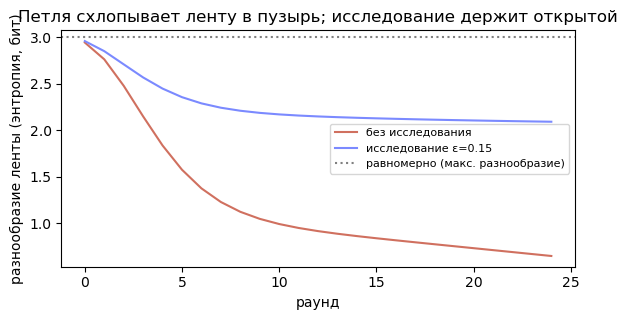

без исследования разнообразие упало с 3.00 до 0.65 бит


In [2]:
N = 8
appeal = np.array([1.6, 1.5, 1.0, 0.95, 0.9, 0.85, 0.8, 0.75])   # насколько тема цепляет

def run_loop(rounds=25, eps=0.0):
    feed = np.ones(N) / N; ent = []
    for _ in range(rounds):
        eng = feed * appeal
        feed = eng / eng.sum()                                   # система показывает больше цепляющего
        if eps: feed = (1 - eps) * feed + eps / N                # исследование: подмешать случайное
        ent.append(entropy(feed))
    return np.array(ent)

fig, ax = plt.subplots(figsize=(6, 3.3))
ax.plot(run_loop(eps=0.0), label="без исследования", color="#d0705f")
ax.plot(run_loop(eps=0.15), label="исследование ε=0.15", color="#7b8aff")
ax.axhline(np.log2(N), ls=":", color="gray", label="равномерно (макс. разнообразие)")
ax.set_xlabel("раунд"); ax.set_ylabel("разнообразие ленты (энтропия, бит)")
ax.set_title("Петля схлопывает ленту в пузырь; исследование держит открытой")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("без исследования разнообразие упало с %.2f до %.2f бит" % (np.log2(N), run_loop(eps=0)[-1]))

Без исследования разнообразие обваливается: пара самых цепляющих тем захватывает ленту. Щепотка случайности держит пузырь открытым — та же роль шума, что у SGD в модуле 4.

**Сломать.** Сделайте `appeal` равным (`appeal[:] = 1`) — пузырь не сложится: без перекоса усиливать нечего.

## 2. Эффект Матфея: богатый богатеет

Товары почти равны по качеству, но стартовая экспозиция чуть-чуть разная. Вовлечение усиливает лидеров, и малое преимущество компаундируется в доминирование. Мера неравенства — коэффициент Джини.

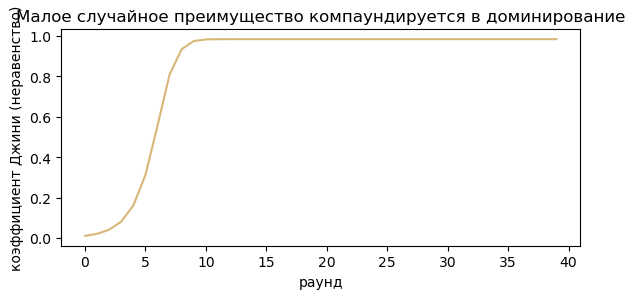

Джини вырос с 0.010 до 0.983: почти равный старт -> горстка захватила показы


In [3]:
rng = np.random.default_rng(0)
M = 60
exposure = np.ones(M) + rng.normal(0, 0.02, M)                  # почти равный старт

def gini(x):
    x = np.sort(x); n = len(x)
    return (2 * np.arange(1, n + 1) - n - 1) @ x / (n * x.sum())

ginis = []
for _ in range(40):
    ginis.append(gini(exposure))
    engagement = exposure                                       # качество равное -> вовлечение = экспозиция
    exposure = exposure * engagement                           # петля усиливает лидеров
    exposure /= exposure.sum() / M

fig, ax = plt.subplots(figsize=(6, 3.1))
ax.plot(ginis, color="#d8b678")
ax.set_xlabel("раунд"); ax.set_ylabel("коэффициент Джини (неравенство)")
ax.set_title("Малое случайное преимущество компаундируется в доминирование")
plt.tight_layout(); plt.show()
print("Джини вырос с %.3f до %.3f: почти равный старт -> горстка захватила показы" % (ginis[0], ginis[-1]))

Из почти равного старта петля вылепила резкое неравенство: те, кому чуть больше повезло вначале, получили больше показов, больше вовлечения, ещё больше показов. Популярность здесь — не только свойство товара, но и след истории показов.

**Сломать.** Верните на каждом раунде немного равномерной экспозиции (исследование) — рост Джини затормозится: тот же приём, что размыкает пузырь.

## 3. Вовлечение против настоящего интереса

Пользователь интересуется широко, но цепляет его узкое. Петля максимизирует вовлечение (прокси) — и охват его настоящих, широких интересов проходит пик и падает. Это Гудхарт из модуля 16 внутри петли.

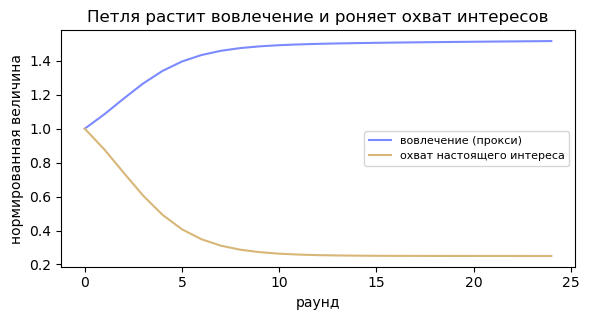

вовлечение выросло в 1.52 раза, охват интересов упал с 1.00 до 0.25


In [4]:
true_interest = np.ones(N) / N                                 # настоящий интерес широк и ровен
feed = np.ones(N) / N
eng_hist, cover_hist = [], []
for _ in range(25):
    eng_hist.append(float(feed @ appeal))                      # вовлечение
    cover_hist.append(float(np.minimum(feed, true_interest).sum()))  # охват настоящего интереса
    e = feed * appeal
    feed = e / e.sum()

fig, ax = plt.subplots(figsize=(6, 3.3))
ax.plot(np.array(eng_hist) / eng_hist[0], label="вовлечение (прокси)", color="#7b8aff")
ax.plot(cover_hist, label="охват настоящего интереса", color="#d8b678")
ax.set_xlabel("раунд"); ax.set_ylabel("нормированная величина")
ax.set_title("Петля растит вовлечение и роняет охват интересов")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("вовлечение выросло в %.2f раза, охват интересов упал с %.2f до %.2f"
      % (eng_hist[-1] / eng_hist[0], cover_hist[0], cover_hist[-1]))

Вовлечение растёт, охват настоящих интересов падает: система всё лучше удерживает внимание и всё хуже служит тому, что человеку на самом деле интересно. Прокси и цель разошлись — ровно кривая Гудхарта из модуля 16, только развёрнутая во времени петли.

## Что дальше

В [модуле 20](https://drobyshevdev.github.io/lemma/programme/) — как честно узнать, что рекомендатель что-то улучшил, а не раскрутил петлю: A/B-тесты, рандомизация, причинность, и те же ловушки, что в модуле 1 — подглядывание и множественные сравнения, но теперь на живых пользователях.